# 02 · Constraints — distances, angles, planes

Bias the embed with soft geometric windows via **`constrain=`** (index-driven — keys are 0-based atom indices; resolve any SMARTS to indices yourself, shown below). Every constraint kind edits RDKit's knowledge-derived bounds matrix (edit, don't replace), so the periphery stays chemically seeded even under a tight custom core. A `constrain` window *biases* the seed (a real energy may overrule it — for a rigid hold use `fix=`, see notebook 04). `measure()` proves each constraint is realised; the **gate** proves the rest of the molecule stays clean.

In [1]:
import tempfile

import numpy as np
import rxembed as rx
import xyzrender
from rdkit import Chem

rx.set_verbose("INFO")

## A distance window (by index)

`distances={(i, j): (lo, hi)}` bounds a pair into a window; a single value becomes a small window. `measure()` reports the realised value across the ensemble.

In [2]:
ACID = "O=C(O)CCCCc1ccccc1"
ens = rx.embed(ACID, constrain={(1, 9): (2.6, 3.0)}).mc().prune()
print("d(1,9) realised:", {k: round(v, 2) for k, v in ens.measure((1, 9)).items()}, "(target 2.6-3.0)")

rxembed | resolve: soft d(C1,C9)->2.60-3.00A
rxembed | embed: 26 seeds (27 atoms, 1 fragment, 1 constraints)
rxembed | mc: +5 (openconf 'ensemble', pose-constrained around seeds; total 31)
rxembed | prune[rmsd]: 31 -> 16  (merged 15 near-duplicates; see .duplicates())


d(1,9) realised: {'mean': 3.0, 'min': 3.0, 'max': 3.01, 'n': 16} (target 2.6-3.0)


## The same contact by SMARTS — resolve the indices yourself

`constrain=` is **index-driven** (no hidden SMARTS matching), so you resolve the SMARTS to atom indices in two RDKit lines, then key by them — transparent, and a symmetric core can't silently flip. Here a carboxylic O–H reaches a pyridine N across two fragments (vdW encounter bounds keep the fragments together automatically). `measure()` still accepts SMARTS — it is only a *query* helper.

In [3]:
smi = "CC(=O)O.c1ccncc1"
mol = Chem.MolFromSmiles(smi)  # resolve SMARTS -> index yourself (two lines), then key constrain= by the index
oh = mol.GetSubstructMatch(Chem.MolFromSmarts("[OX2H]"))[0]
n = mol.GetSubstructMatch(Chem.MolFromSmarts("n"))[0]
ens = rx.embed(smi, constrain={(oh, n): (2.6, 3.0)}).mc().prune()
print("d(OH..n) realised:", {k: round(v, 2) for k, v in ens.measure((oh, n)).items()})

rxembed | resolve: soft d(O3,N7)->2.60-3.00A
rxembed | embed: 40 seeds (19 atoms, 2 fragments, 1 constraints)
rxembed | mc: +26 (openconf 'ensemble', pose-constrained around seeds; total 66)
rxembed | prune[rmsd]: 66 -> 7  (merged 59 near-duplicates; see .duplicates())


d(OH..n) realised: {'mean': 3.0, 'min': 3.0, 'max': 3.0, 'n': 7}


## An angle

`angles={(i, j, k): value}` — a single value becomes a small window (law-of-cosines leg in the bounds matrix).

In [4]:
ens = rx.embed(ACID, constrain={(2, 1, 0): 120}).mc().prune()
print("angle(2,1,0) realised:", {k: round(v, 1) for k, v in ens.measure((2, 1, 0)).items()}, "(target 120)")

rxembed | resolve: soft angle(O2,C1,O0)->115.0-125.0deg
rxembed | embed: 38 seeds (27 atoms, 1 fragment, 1 constraints)
rxembed | mc: +50 (openconf 'ensemble', pose-constrained around seeds; total 88)
rxembed | prune[rmsd]: 88 -> 47  (merged 41 near-duplicates; see .duplicates())


angle(2,1,0) realised: {'mean': 119.8, 'min': 119.1, 'max': 120.0, 'n': 47} (target 120)


## Planes — a π-stack (the parallel-plane constraint)

`planes=[(ring_a, ring_b, separation)]` holds two rings parallel at a target separation — matched atom-for-atom, so pass the ring atoms in a **consistent order** (a SMARTS match gives that). Here the two phenyls of 1,4-diphenylbutane are stacked at 3.7 Å.

rxembed | resolve: stack 6x6 ring @ 3.7A
rxembed | embed: 15 seeds (34 atoms, 1 fragment, 0 constraints)
rxembed | mc: +1 (openconf 'ensemble', pose-constrained around seeds; total 16)
rxembed | prune[rmsd]: 16 -> 7  (merged 9 near-duplicates; see .duplicates())


pi-stack centroid separation: 3.59-3.93 A  (7 confs, target 3.7)
geometry.check: CLEAN


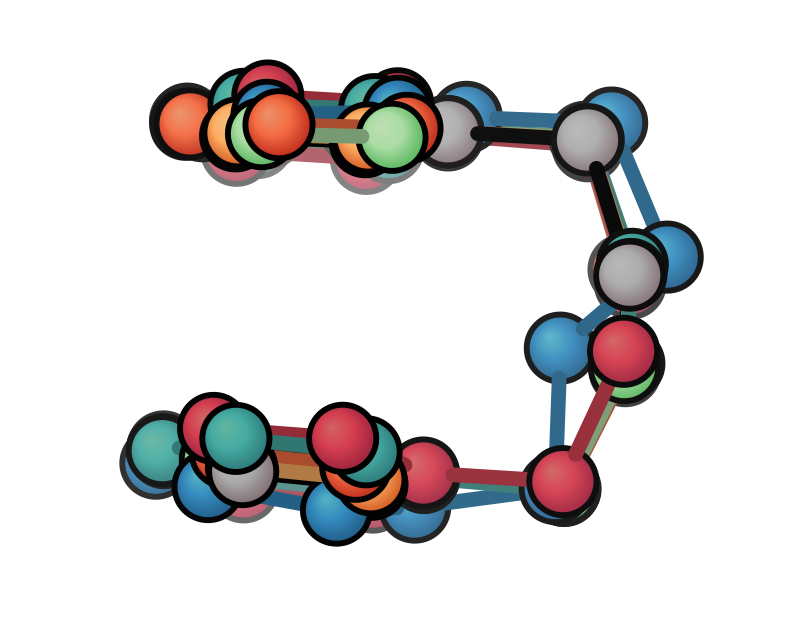

In [5]:
smi = "c1ccccc1CCCCc1ccccc1"
mol = Chem.AddHs(Chem.MolFromSmiles(smi))
ra, rb = [tuple(m) for m in mol.GetSubstructMatches(Chem.MolFromSmarts("c1ccccc1"))]  # the two phenyl rings
ens = rx.embed(smi, constrain={(ra, rb): 3.7}).mc(preset="ensemble").prune()  # a parallel pi-stack at 3.7 A
seps = [
    float(
        np.linalg.norm(
            ens.mol.GetConformer(c).GetPositions()[list(ra)].mean(0)
            - ens.mol.GetConformer(c).GetPositions()[list(rb)].mean(0)
        )
    )
    for c in ens.ids
]
print(f"pi-stack centroid separation: {min(seps):.2f}-{max(seps):.2f} A  ({len(ens)} confs, target 3.7)")
rep = rx.geometry.check(ens.mol, conf_id=ens.ids[0])  # the stacked rings stay planar and clash-free
print("geometry.check:", "CLEAN" if rep.ok() else f"FAIL {rep.violations[:6]}")
xyzrender.render(
    xyzrender.load(ens.dump(tempfile.mktemp(suffix=".xyz")), ensemble=True, ensemble_color="spectral", nci_detect=True),
    no_hy=True,
)  # the pi-contact drawn

## Incremental relaxing, and fail-loud

A **tight** (over-constrained) core still embeds — the triangle smoothing escalates tolerance until the bounds are metric-feasible. A **genuinely impossible** set (here a C–C bond stretched to 5 Å) fails loud rather than silently embedding a broken geometry.

In [6]:
tight = rx.embed(ACID, constrain={(1, 9): (2.70, 2.75)}).mc(preset="rapid").prune()  # a very tight window
print("tight window still embeds:", len(tight), "confs; d(1,9) =", round(tight.measure((1, 9))["mean"], 2))
try:
    rx.embed("CCO", constrain={(0, 1): (5.0, 5.5)}).mc()  # a C-C bond forced to 5 A - impossible
except (ValueError, RuntimeError) as e:
    print("impossible constraint fails loud:", type(e).__name__, "-", str(e)[:55])

rxembed | resolve: soft d(C1,C9)->2.70-2.75A
rxembed | embed: 24 seeds (27 atoms, 1 fragment, 1 constraints)
rxembed | mc: preset='rapid' on a constrained system under-samples (pose-mode is rotor-only); 'ensemble' (the default) is recommended for a constrained run
rxembed | mc: +5 (openconf 'rapid', pose-constrained around seeds; total 29)
rxembed | prune[rmsd]: 29 -> 17  (merged 12 near-duplicates; see .duplicates())
rxembed | resolve: soft d(C0,C1)->5.00-5.50A


tight window still embeds: 17 confs; d(1,9) = 2.76
impossible constraint fails loud: RuntimeError - triangle smoothing failed


## The gate on a constrained periphery

The whole point: a seeded contact must not distort the rest of the molecule. The gate confirms the constrained embed's periphery is clean.

In [7]:
ens = rx.embed(ACID, constrain={(1, 9): (2.6, 3.0)}).mc().minimize()
rep = rx.geometry.check(ens.mol, conf_id=ens.ids[0])
print("geometry.check:", "CLEAN" if rep.ok() else f"FAIL {rep.violations[:6]}")

rxembed | resolve: soft d(C1,C9)->2.60-3.00A
rxembed | embed: 26 seeds (27 atoms, 1 fragment, 1 constraints)
rxembed | mc: +10 (openconf 'ensemble', pose-constrained around seeds; total 36)


geometry.check: CLEAN
